In [1]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv")
JSON_DIR = os.path.join(ROOT, "json")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
from src.weather_data_download import download_station_data, cast_columns
import random
from datetime import datetime
import pandas as pd
import json
import time
import matplotlib.pyplot as plt

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


### Exploring station codes

In [10]:
locations_dict = os.path.join(JSON_DIR, "locations.json")
with open(locations_dict, "r", encoding="utf-8") as f:
    locations_df = pd.DataFrame(
        list(json.load(f).items()),
        columns=["code", "location"]
    )

display(locations_df.sample(5))

,code,location
723,B605X,MURO-S?ALBUFERA
350,4468X,PUEBLA DE OBANDO (AUTOMATICA)
439,5983X,MEDINA SIDONIA (EL HUNDIDO - AUTOMATICA)
97,1249X,OVIEDO
203,2536D,MORALES DEL TORO-DEPOSITO


### Querying up to 6 months

In [3]:
client = AemetClient(API_KEY)
station_id = "1442U"
start_date = "2024-01-01"
n_dias = 180  # each query supports approximately 6 months of data
end_date = (datetime.strptime(start_date, "%Y-%m-%d") + pd.Timedelta(days=n_dias)).strftime("%Y-%m-%d")
data = pd.DataFrame(client.fetch_station_history(station_id, start_date, end_date))
display(data.head(5))
print("...")
display(data.tail(5))
last_date = pd.to_datetime(data['fecha']).iloc[-1]
print(last_date)

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
0,2024-01-01,1442U,BOIRO,A CORUÑA,10,"9,6","2,6","5,7",00:16,"13,6",16:08,88,98,09:00,77,16:00,"6,0",08:55
1,2024-01-02,1442U,BOIRO,A CORUÑA,10,"14,2","30,6","13,2",00:08,"15,1",14:06,92,96,Varias,84,Varias,"20,4",13:55
2,2024-01-03,1442U,BOIRO,A CORUÑA,10,"12,0","2,0","9,1",21:34,"14,8",15:05,85,96,22:20,78,09:50,"3,6",07:15
3,2024-01-04,1442U,BOIRO,A CORUÑA,10,"10,5","12,8","6,7",22:43,"14,3",10:17,88,93,Varias,69,15:00,"18,0",10:45
4,2024-01-05,1442U,BOIRO,A CORUÑA,10,"7,6","1,8","3,7",23:59,"11,5",12:35,91,98,09:30,78,16:30,"3,6",12:40


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
176,2024-06-25,1442U,BOIRO,A CORUÑA,10,"18,2","0,2","16,6",06:08,"19,9",00:01,88,94,08:20,81,13:30,"0,0",NaN
177,2024-06-26,1442U,BOIRO,A CORUÑA,10,"20,8","0,0","16,8",04:18,"24,8",14:15,79,94,Varias,65,14:20,"1,2",05:35
178,2024-06-27,1442U,BOIRO,A CORUÑA,10,"23,1","0,0","18,1",04:31,"28,1",12:10,69,82,04:40,57,11:50,"0,0",NaN
179,2024-06-28,1442U,BOIRO,A CORUÑA,10,"22,6","0,0","17,6",05:04,"27,5",14:35,65,78,01:40,55,13:10,"0,0",NaN
180,2024-06-29,1442U,BOIRO,A CORUÑA,10,"21,2","5,8","16,5",04:08,"26,0",12:52,63,93,Varias,51,13:00,"2,4",23:40


2024-06-29 00:00:00


### Retrieving 6+ months of historical data

In [2]:
client = AemetClient(API_KEY)
station_id = "2059B"
df = download_station_data(client, station_id=station_id, start_date="2020-01-01", end_date="2020-12-31",
                            max_retries=5, sleep_seconds=6)

Fetching data for station 2059B from 2020-01-01 to 2020-06-28...
✓ Retrieved 180 records (from 2020-01-01 to 2020-06-28)
Fetching data for station 2059B from 2020-06-29 to 2020-12-25...
✓ Retrieved 180 records (from 2020-06-29 to 2020-12-25)
Fetching data for station 2059B from 2020-12-26 to 2021-06-23...
✓ Retrieved 178 records (from 2020-12-26 to 2021-06-23)
Reached end_date (2020-12-31). Trimmed rows beyond end_date and stopping.

Final dataset: 366 records


In [3]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
0,2020-01-01,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"4,6","0,0","-5,4",07:26,"14,6",...,"0,6","5,6",13:50,56,87,00:50,27,13:50,"0,0",NaN
1,2020-01-02,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"5,1","0,0","-4,0",05:43,"14,2",...,"2,2","6,1",16:30,60,88,Varias,37,13:30,"0,0",NaN
2,2020-01-03,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"1,8","0,0","-1,0",05:58,"4,7",...,"3,1","8,3",08:20,91,98,Varias,63,00:00,"0,0",NaN


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
363,2020-12-29,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"0,9","0,4","-1,5",23:59,"3,3",...,"8,6","15,8",12:00,78,96,16:30,73,Varias,"1,2",Varias
364,2020-12-30,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"-0,1","0,0","-2,3",05:18,"2,1",...,"6,4","16,7",02:00,83,91,05:20,76,Varias,"0,0",NaN
365,2020-12-31,2059B,LA RIBA DE ESCALOTE,SORIA,1042,"2,4","3,2","-0,5",Varias,"5,2",...,"6,4","12,5",12:50,85,98,Varias,72,12:30,"2,4",Varias


### Casting column formats

In [4]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: object
indicativo: object
nombre: object
provincia: object
altitud: object
tmed: object
prec: object
tmin: object
horatmin: object
tmax: object
horatmax: object
dir: object
velmedia: object
racha: object
horaracha: object
hrMedia: object
hrMax: object
horaHrMax: object
hrMin: object
horaHrMin: object
pintMax: object
horaPIntMax: object


In [5]:
schema_path = os.path.join(JSON_DIR, "data-fields.json")
df = cast_columns(df, schema_path)

In [6]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
dir: Int64
velmedia: Float64
racha: Float64
horaracha: string
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string
pintMax: object
horaPIntMax: object


In [7]:
df.to_csv(os.path.join(CSV_DIR,f"hist_{station_id}_2020_data.csv"), index=False)

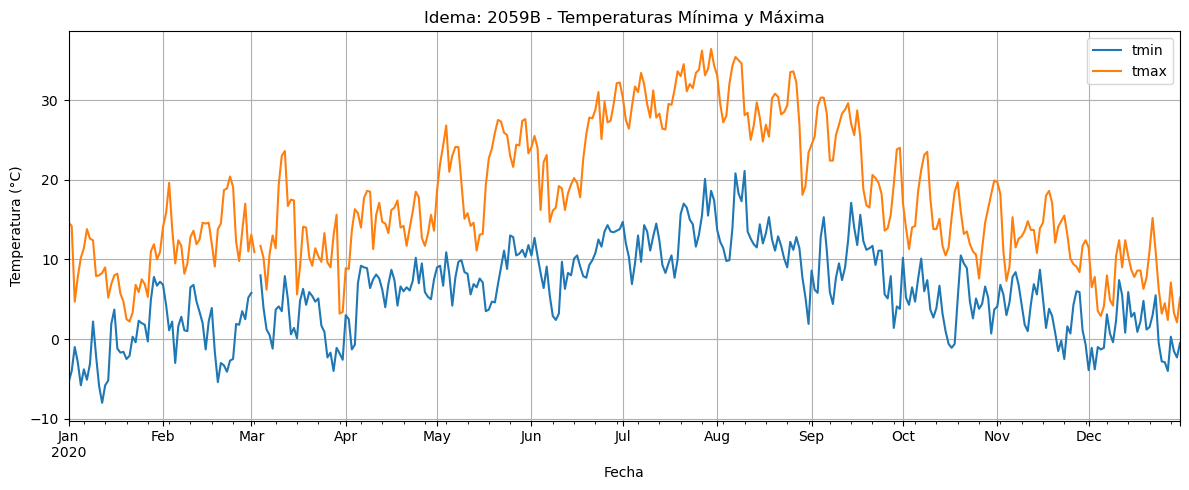

In [8]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### Testing a second location

In [11]:
display(locations_df.sample(3))

,code,location
79,1178I,VEGA DE URRIELLU PARQUE NACIONAL PICOS DE EUROPA
163,2030,SORIA
356,4499X,MONESTERIO (AUTOMATICA)


In [13]:
station_id = "4499X"
df_sample = download_station_data(client, station_id=station_id, start_date="2020-01-01", 
                                  end_date="2020-12-31", max_retries=5, sleep_seconds=6)

Fetching data for station 4499X from 2020-01-01 to 2020-06-28...
✓ Retrieved 180 records (from 2020-01-01 to 2020-06-28)
Fetching data for station 4499X from 2020-06-29 to 2020-12-25...
✓ Retrieved 180 records (from 2020-06-29 to 2020-12-25)
Fetching data for station 4499X from 2020-12-26 to 2021-06-23...
✓ Retrieved 180 records (from 2020-12-26 to 2021-06-23)
Reached end_date (2020-12-31). Trimmed rows beyond end_date and stopping.

Final dataset: 366 records


In [17]:
display(df_sample.head(3))
print("...")
display(df_sample.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
0,2020-01-01,4499X,MONESTERIO,BADAJOZ,771,"10,6","0,0","4,6",06:00,"16,7",...,"1,4","4,2",01:40,69,93,21:50,49,14:00,"0,0",NaN
1,2020-01-02,4499X,MONESTERIO,BADAJOZ,771,"8,9","0,0","4,0",07:12,"13,8",...,"1,1","4,2",12:00,75,97,23:30,63,13:00,"0,0",NaN
2,2020-01-03,4499X,MONESTERIO,BADAJOZ,771,"7,4","0,0","5,8",23:40,"8,9",...,"1,4","6,4",15:30,87,97,Varias,76,15:10,"0,0",NaN


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
363,2020-12-29,4499X,MONESTERIO,BADAJOZ,771,"4,0","0,4","0,7",23:58,"7,2",...,"3,3","9,2",09:40,91,100,08:50,77,14:30,"1,2",Varias
364,2020-12-30,4499X,MONESTERIO,BADAJOZ,771,"3,2","0,0","0,0",Varias,"6,5",...,"2,2","7,5",Varias,78,98,Varias,60,15:40,"0,0",NaN
365,2020-12-31,4499X,MONESTERIO,BADAJOZ,771,"3,9","2,8","1,1",03:21,"6,7",...,"3,3","10,6",22:10,92,98,Varias,88,Varias,"4,8",21:05


In [19]:
df = df_sample.copy()
date_cols = ["fecha"]
text_cols = ["indicativo", "nombre", "provincia"]
int_cols = ["altitud", "dir", "hrMedia", "hrMax", "hrMin"]
float_cols = ["tmed", "prec", "tmin", "tmax", "velmedia", "racha", "sol", "presMax", "presMin"]
time_cols = ["horatmin", "horatmax", "horaracha", "horaPresMax", "horaPresMin", "horaHrMax", "horaHrMin"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

for col in int_cols:
    if col in df.columns:
        df[col] = (
            pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
            .astype("Int64")
        )

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

for col in time_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()
df_sample= df.copy()

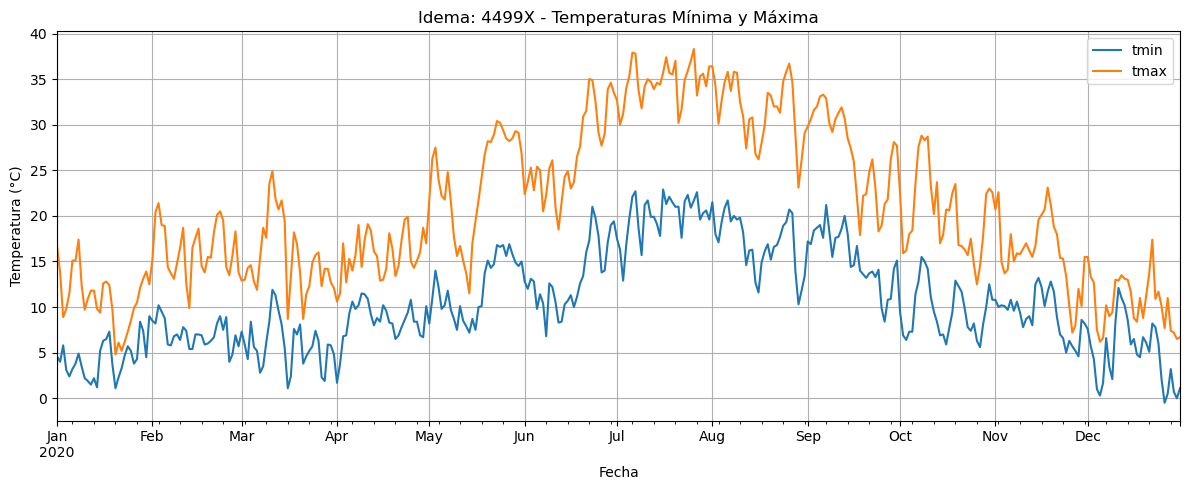

In [20]:
ax = df_sample.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

In [21]:
df_sample.to_csv(os.path.join(CSV_DIR,f"hist_{station_id}_2020_data.csv"), index=False)

### Download until most recent date